In [13]:
import operator
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Any, Annotated, Dict, Literal
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from pydantic import BaseModel, Field

In [2]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int
    equation: str
    determinant: float
    result: str

In [8]:
def quadratic_equation_node(state: QuadState):
    equation =f"{state['a']}x2+{state['b']}x+{state['c']}"
    return {"equation":equation}

In [9]:
def determinant_node(state: QuadState):
    a = state['a']
    b = state['b']
    c = state['c']
    
    determinant=(b*b)-(4*a*c)
    
    return {"determinant": determinant}

In [11]:
def no_real_roots_node(state: QuadState):
    result=f"there is no real roots"
    return {"result":result}

In [12]:
def one_real_root_node(state: QuadState):
    root = -state['b']/2*state['a']
    result=f"repeated root is {root}"
    return {"result":result}

In [10]:
def two_real_roots_node(state: QuadState):
    root1= -state['b']+state['determinant']/(2*state['a'])
    root2= -state['b']-state['determinant']/(2*state['a'])
    result=f"roots are {root1} and {root2}"
    return {"result": result}

In [15]:
def check_condition(state: QuadState):
    if state['determinant'] > 0:
        return "two_roots"
    elif state['determinant'] == 0:
        return "one_root"
    else:
        return "no_roots"

In [20]:
graph=StateGraph(QuadState)

graph.add_node("quadratic_equation_node",quadratic_equation_node)
graph.add_node("determinant_node",determinant_node)
graph.add_node("no_real_roots_node",no_real_roots_node)
graph.add_node("one_real_root_node",one_real_root_node)
graph.add_node("two_real_roots_node",two_real_roots_node)

graph.add_edge(START,"quadratic_equation_node")
graph.add_edge("quadratic_equation_node","determinant_node")
graph.add_conditional_edges("determinant_node", check_condition, {
    "two_roots" : "two_real_roots_node",
    "one_root" : "one_real_root_node",
    "no_roots" : "no_real_roots_node"
})

In [27]:
workflow=graph.compile()

initial_state={
    "a":5,
    "b":-44,
    "c":1
}

In [28]:
result=workflow.invoke(initial_state)

In [29]:
result

{'a': 5,
 'b': -44,
 'c': 1,
 'equation': '5x2+-44x+1',
 'determinant': 1916,
 'result': 'roots are 235.6 and -147.6'}

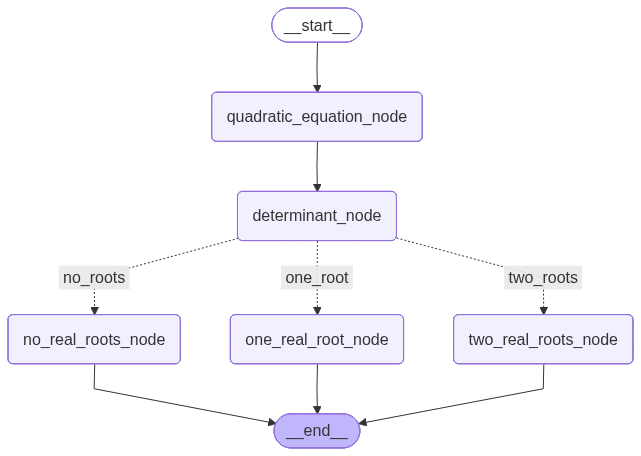

In [30]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())